# Why matter is stable: the uncertainty principle holds the atom open
### one plot explains why the electron doesn't fall into the nucleus

Classically an atom should **collapse**: the Coulomb energy $-ke^2/r$ dives to $-\infty$ as
the electron falls toward $r=0$, and a circling charge radiates its energy away. Matter
should not exist. It does, and the reason is the **uncertainty principle**: pin the electron
into a region of size $r$ and its momentum must spread by $\Delta p\sim\hbar/r$, so it is
forced to carry kinetic energy
$$KE\sim\frac{(\Delta p)^2}{2m}=\frac{\hbar^2}{2mr^2}.$$
Squeeze smaller and this cost grows as $1/r^2$ — **faster** than the Coulomb energy drops
as $1/r$. So the total
$$E(r)=\frac{\hbar^2}{2mr^2}-\frac{Zke^2}{r}$$
turns around and has a **finite minimum**. This notebook plots exactly that, using
`dgs/stability_of_matter.py`, and shows the minimum lands — with no fitted constants — on
the Bohr radius and $-13.6$ eV. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import stability_of_matter as sm
eV = sm.EV_J
print("Bohr radius = %.4e m,  ground state = %.4f eV" %
      (sm.bohr_radius(1), sm.ground_state_energy_eV(1)))

Bohr radius = 5.2918e-11 m,  ground state = -13.6057 eV


## 1. Two terms fight, and quantum mechanics wins

The kinetic term (blue, $+1/r^2$) and the Coulomb term (orange, $-1/r$) pull in opposite
directions. Their sum (black) is the energy the atom actually has. Where the black curve
bottoms out is the ground state — marked at the Bohr radius $a_0$, at $-13.6$ eV.

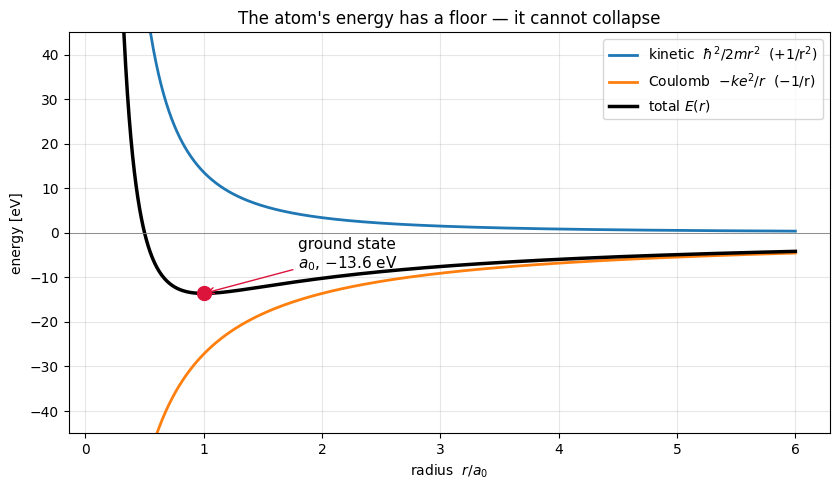

In [2]:
a0 = sm.bohr_radius(1)
r = np.linspace(0.15*a0, 6*a0, 800)
KE = sm.kinetic_energy(r) / eV
Coul = sm.coulomb_energy(r, 1) / eV
E = sm.total_energy(r, 1) / eV

plt.figure(figsize=(8.5, 5))
plt.plot(r/a0, KE,  lw=2, label="kinetic  $\\hbar^2/2mr^2$  (+1/r$^2$)")
plt.plot(r/a0, Coul, lw=2, label="Coulomb  $-ke^2/r$  ($-$1/r)")
plt.plot(r/a0, E,   lw=2.5, color="k", label="total $E(r)$")
plt.axhline(0, color="gray", lw=0.6)
plt.plot(1.0, sm.ground_state_energy_eV(1), "o", ms=10, color="crimson", zorder=5)
plt.annotate("ground state\n$a_0$, $-13.6$ eV", (1.0, sm.ground_state_energy_eV(1)),
             xytext=(1.8, -8), fontsize=11,
             arrowprops=dict(arrowstyle="->", color="crimson"))
plt.ylim(-45, 45); plt.xlabel("radius  $r / a_0$"); plt.ylabel("energy [eV]")
plt.title("The atom's energy has a floor — it cannot collapse")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 2. The minimum IS the Bohr atom — found numerically

We never plug in the Bohr formula: we just **minimize the curve** $E(r)$. It lands on
$a_0=5.2918\times10^{-11}$ m and $-13.6057$ eV, the measured hydrogen ground state. The
"sloppy" uncertainty estimate is exact here because the Coulomb $1/r$ makes the balance
tip precisely.

In [3]:
r_num, E_num = sm.minimize_numerically(1)
print("numerical minimum : r = %.5e m,  E = %.4f eV" % (r_num, E_num/eV))
print("analytic Bohr atom: r = %.5e m,  E = %.4f eV" %
      (sm.bohr_radius(1), sm.ground_state_energy_eV(1)))
print("match:", np.isclose(r_num, sm.bohr_radius(1), rtol=1e-3),
      np.isclose(E_num, sm.ground_state_energy(1), rtol=1e-3))

# virial theorem at the minimum: KE = -E, PE = 2E
ke_r, pe_r = sm.virial_ratios(1)
print("virial: KE/|E| = %+.3f (=+1),  PE/|E| = %+.3f (=-2)" % (ke_r, pe_r))

numerical minimum : r = 5.29177e-11 m,  E = -13.6057 eV
analytic Bohr atom: r = 5.29177e-11 m,  E = -13.6057 eV
match: True True
virial: KE/|E| = +1.000 (=+1),  PE/|E| = -2.000 (=-2)


## 3. The classical catastrophe (for contrast)

Turn OFF the quantum kinetic term and you get the Coulomb well alone — it just keeps
falling, no bottom, $E\to-\infty$ as $r\to0$. That is the classical prediction: the
electron radiates and spirals in. The $1/r^2$ kinetic floor is the *only* thing that
stops it.

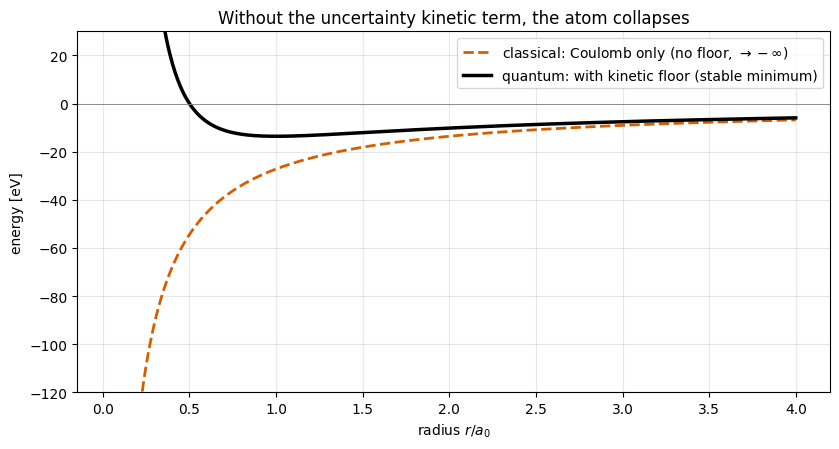

In [4]:
r2 = np.linspace(0.05*a0, 4*a0, 800)
plt.figure(figsize=(8.5, 4.6))
plt.plot(r2/a0, sm.coulomb_energy(r2, 1)/eV, "--", lw=2, color="#D55E00",
         label="classical: Coulomb only (no floor, $\\to-\\infty$)")
plt.plot(r2/a0, sm.total_energy(r2, 1)/eV, lw=2.5, color="k",
         label="quantum: with kinetic floor (stable minimum)")
plt.axhline(0, color="gray", lw=0.6)
plt.ylim(-120, 30); plt.xlabel("radius $r/a_0$"); plt.ylabel("energy [eV]")
plt.title("Without the uncertainty kinetic term, the atom collapses")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. Heavier nuclei: tighter and deeper as $Z^2$

A larger nuclear charge $Z$ pulls the electron in ($r_{min}=a_0/Z$) and deepens the well
($E=-13.6\,Z^2$ eV). The energy curves nest inside each other — the same balance, scaled.

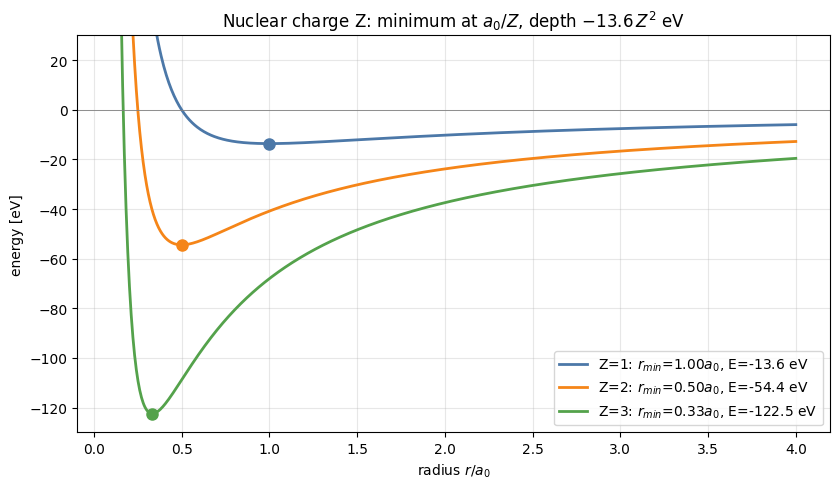

In [5]:
plt.figure(figsize=(8.5, 5))
rr = np.linspace(0.1*a0, 4*a0, 800)
for Z, c in zip((1, 2, 3), ["#4C78A8", "#F58518", "#54A24B"]):
    plt.plot(rr/a0, sm.total_energy(rr, Z)/eV, lw=2, color=c,
             label=f"Z={Z}: $r_{{min}}$={sm.bohr_radius(Z)/a0:.2f}$a_0$, "
                   f"E={sm.ground_state_energy_eV(Z):.1f} eV")
    plt.plot(sm.bohr_radius(Z)/a0, sm.ground_state_energy_eV(Z), "o", ms=8, color=c)
plt.axhline(0, color="gray", lw=0.6)
plt.ylim(-130, 30); plt.xlabel("radius $r/a_0$"); plt.ylabel("energy [eV]")
plt.title("Nuclear charge Z: minimum at $a_0/Z$, depth $-13.6\\,Z^2$ eV")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## What the plot says

* The Coulomb well alone has **no bottom** — classically the atom collapses.
* The uncertainty principle forces a kinetic energy $\hbar^2/2mr^2$ that **grows faster**
  ($1/r^2$) than Coulomb falls ($1/r$), so $E(r)$ has a **finite minimum**.
* Minimizing it — no fitted constants — gives the **Bohr radius** and **$-13.6$ eV**, with
  the **virial theorem** ($KE=-E$, $PE=2E$) holding at the bottom.
* Scaling with $Z$ nests the wells: tighter and deeper as $Z^2$.

This is stability of matter at one atom — the same quantum kinetic floor that holds up
solids and white dwarfs, and the sibling of the zero-point energy $\tfrac12\hbar\omega$ in
`dgs/quantum_oscillator.py`.